# Project #1: Exploratory Data Analysis on Credit Card Fraud Data  
### Submitted by: Sanobar Shaikh  

---

## Business Goal  
Credit card fraud poses a significant threat to financial institutions, costing billions annually in unauthorized transactions and customer reimbursements. The ability to detect such fraud early—by understanding how it manifests in transaction data—is a critical first step in building effective fraud prevention systems.

This project focuses on uncovering hidden patterns in a real-world credit card transaction dataset through **Exploratory Data Analysis (EDA)**. The objective is to identify data behaviors that distinguish fraudulent activity from legitimate transactions, providing foundational insights for downstream machine learning models and risk strategies.

---

## Project Overview  
In this notebook, I perform a detailed exploratory analysis of the **Kaggle Credit Card Fraud Detection Dataset**, which contains anonymized transactions made by European cardholders. Most of the input features are PCA-transformed to preserve confidentiality, and the dataset is highly imbalanced—fraud cases account for less than 0.2% of all records.

Key areas of analysis include:  

- **Understanding Data Distribution**: Summary statistics and structural review of key variables (`Amount`, `Time`, `Class`)  
- **Class Imbalance Analysis**: Evaluating fraud-to-non-fraud ratio and implications for model training  
- **Behavioral Patterns**: Using boxplots and histograms to compare transaction amounts and time-based behaviors across fraud classes  
- **Feature Relationships**: Correlation heatmap to uncover feature dependencies and inform feature selection  

This EDA not only supports the development of robust fraud detection models but also demonstrates my ability to apply data science techniques to solve high-stakes financial problems with real-world impact.

---

## Dataset Summary  
**Source**: [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
- **Rows**: 284,807 transactions  
- **Features**:  
  - `Time`: Seconds from first transaction  
  - `Amount`: Transaction value  
  - `V1` to `V28`: PCA components representing confidential transaction details  
  - `Class`: Binary label (1 = Fraud, 0 = Legitimate)

---

By the end of this analysis, I provide key insights into how fraudulent transactions differ in structure and behavior from normal ones—setting the stage for predictive modeling, anomaly detection, and operational risk management in digital banking environments.


### Task1 : Import the Dataset

In [3]:
# Import necessary libraries 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset

df = pd.read_csv("creditcard.csv")

# Preview the data
print(df.head())  # Display top 5 rows of the dataframe



   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

### Task 2: Summary Statistics

In [ ]:
# Descriptive statistics Summary for entire dataset

print(df.describe())


Interpretation of summary statistics:

1. Class Imbalance - Fraud Cases: Only ~0.17% (Class column mean = 0.001727), 
indicating a highly imbalanced dataset whereas Non-Fraud Cases are in Majority.

2. Amount Column: Mean = $88.35, StdDev = $250.12, Max = $25691.16 that means data is right-skewed.

The distribution of amounts for fraud cases is more concentrated at the lower end, 
while non-fraudulent transactions span a wider range and include higher values. 
This means most high-value transactions are legitimate, and fraud is more common in smaller transactions

3. 75% of transactions are below $77.17 — confirms long-tail distribution.

4. Time Column: Ranges from 0 to ~172792.00 seconds (≈ 48 hours) — reflects the time elapsed 
since the first transaction.

#### Interpret any differences between fraudulent and non-fraudulent transactions 

In [4]:

# Describe summary statistics for non-fraudulent classes separately 

df[df['Class'] == 0].describe()  # Non-fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,...,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.0
mean,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,0.0
std,47484.015786,1.929814,1.636146,1.459429,1.399333,1.356952,1.329913,1.178812,1.161283,1.089372,...,0.716743,0.723668,0.621541,0.605776,0.520673,0.482241,0.399847,0.329570,250.105092,0.0
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0
25%,54230.000000,-0.917544,-0.599473,-0.884541,-0.850077,-0.689398,-0.766847,-0.551442,-0.208633,-0.640412,...,-0.228509,-0.542403,-0.161702,-0.354425,-0.317145,-0.327074,-0.070852,-0.052950,5.650000,0.0
50%,84711.000000,0.020023,0.064070,0.182158,-0.022405,-0.053457,-0.273123,0.041138,0.022041,-0.049964,...,-0.029821,0.006736,-0.011147,0.041082,0.016417,-0.052227,0.001230,0.011199,22.000000,0.0
75%,139333.000000,1.316218,0.800446,1.028372,0.737624,0.612181,0.399619,0.571019,0.326200,0.598230,...,0.185626,0.528407,0.147522,0.439869,0.350594,0.240671,0.090573,0.077962,77.050000,0.0
max,172792.000000,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,...,22.614889,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0


In [5]:
# Describe summary statistics for fraudulent classes separately 

df[df['Class'] == 1].describe()  # Fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


### Task 3 :Boxplot

Plot a boxplot comparing the Amount variable by Class (fraud vs. non-fraud).
Identify any outliers or unusual distributions

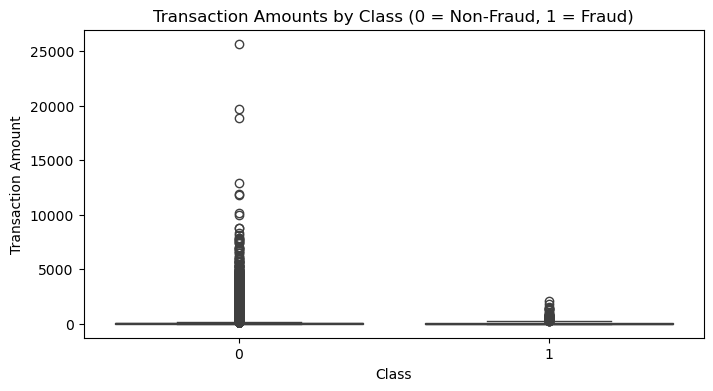

In [6]:
# Set the figure size
plt.figure(figsize=(8, 4))

# Create boxplot comparing Amount by Class
sns.boxplot(x='Class', y='Amount', data=df)

# Add title and labels
plt.title('Transaction Amounts by Class (0 = Non-Fraud, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Transaction Amount')

# Display the plot
plt.show()



### Identifying Outliers and treating them by applying 1.5 IQR Rule

In [7]:
# To handle imbalance and skewness in data, Apply IQR filtering(1.5 IQR Rule) on 'Amount' 

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

#Creating another dataframe to store capped results 

df_clean = df[(df['Amount'] >= Q1 - 1.5 * IQR) & (df['Amount'] <= Q3 + 1.5 * IQR)]

# Summary statistics for new dataframe 
#To detect how much outlier removal has changed the data distribution -

print(df_clean.describe())


                Time             V1             V2             V3  \
count  252903.000000  252903.000000  252903.000000  252903.000000   
mean    94986.492228       0.094504       0.230435       0.060689   
std     47594.978003       1.820271       1.293522       1.471043   
min         0.000000     -40.470142     -47.429676     -33.680984   
25%     54533.500000      -0.859648      -0.397907      -0.816557   
50%     85041.000000       0.035238       0.165842       0.225603   
75%    139586.000000       1.356675       0.878353       1.067617   
max    172788.000000       2.454930      22.057729       4.226108   

                  V4             V5             V6             V7  \
count  252903.000000  252903.000000  252903.000000  252903.000000   
mean       -0.019030       0.116567      -0.059286      -0.083767   
std         1.393801       1.214682       1.264431       1.038737   
min        -5.683171     -23.669726     -23.496714     -43.557242   
25%        -0.850251      -0.5674

### Create boxplot with IQR Capped data for Amount

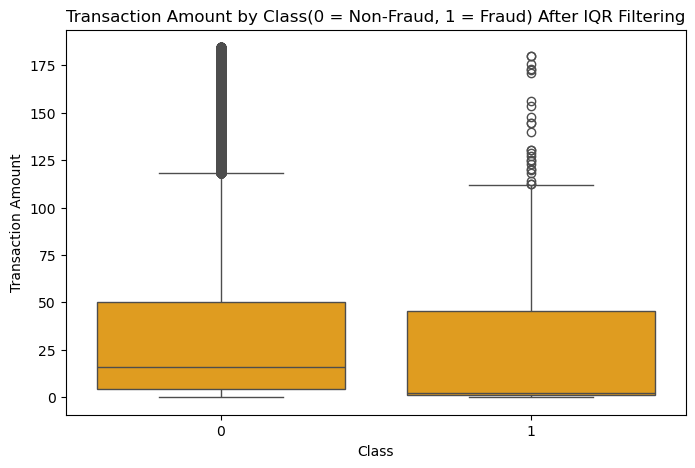

In [8]:
# Set the figure size

plt.figure(figsize=(8, 5))

# Create boxplot comparing Amount by Class

sns.boxplot(x='Class', y='Amount', data=df_clean,color = 'orange')


# Add title and labels
plt.title("Transaction Amount by Class(0 = Non-Fraud, 1 = Fraud) After IQR Filtering")
plt.xlabel('Class')
plt.ylabel('Transaction Amount')

plt.show()


Interpretation of BoxPlot -

This distribution for Class 1 (Fraud) is heavily right-skewed. Most of the values are small and close together.
A few much larger values pull the upper tail, creating the long stretch upward.

It implies -

1. Most frauds are at a consistent lower amount (same value repeated or batched)
2. A few are higher-value frauds
3. Suggests a fraud pattern like "micro frauds" (many small, consistent withdrawals or charges)


### Task 4. Histogram 

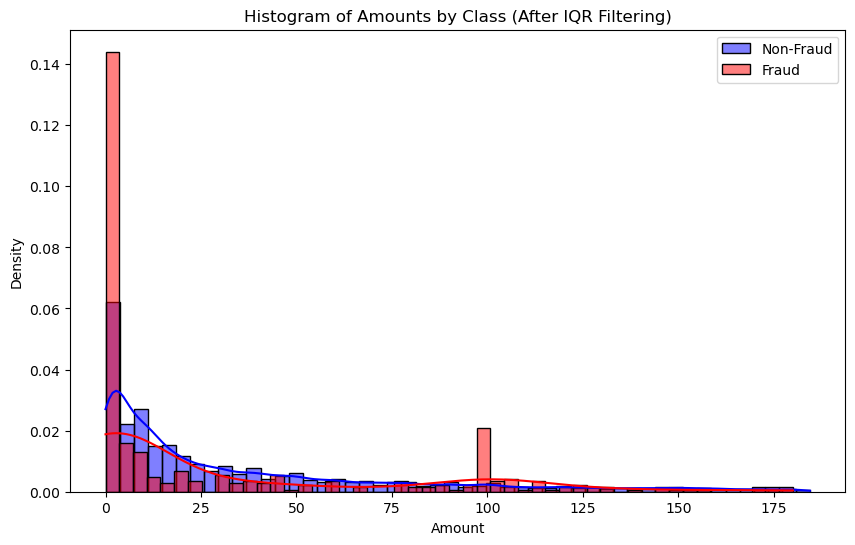

In [9]:
# Histogram

# Set the figure size
plt.figure(figsize=(10, 6))

# Create Histogram overlay comparing Amount by Class

sns.histplot(df_clean[df_clean['Class'] == 0]['Amount'], kde=True, stat='density', bins=50, label='Non-Fraud', color='blue')
sns.histplot(df_clean[df_clean['Class'] == 1]['Amount'], kde=True, stat='density', bins=50, label='Fraud', color='red')

# Add title and labels

plt.title("Histogram of Amounts by Class (After IQR Filtering)")
plt.legend()
plt.show()

Interpretation of histogram 

1. Non-fraud transactions dominate and span a much wider range of amounts.
2. Fraud transactions are fewer but often centered around specific higher-value ranges.
3. Most transactions (fraud and non-fraud) are low-value (< $100).


### Task 5. Heatmap

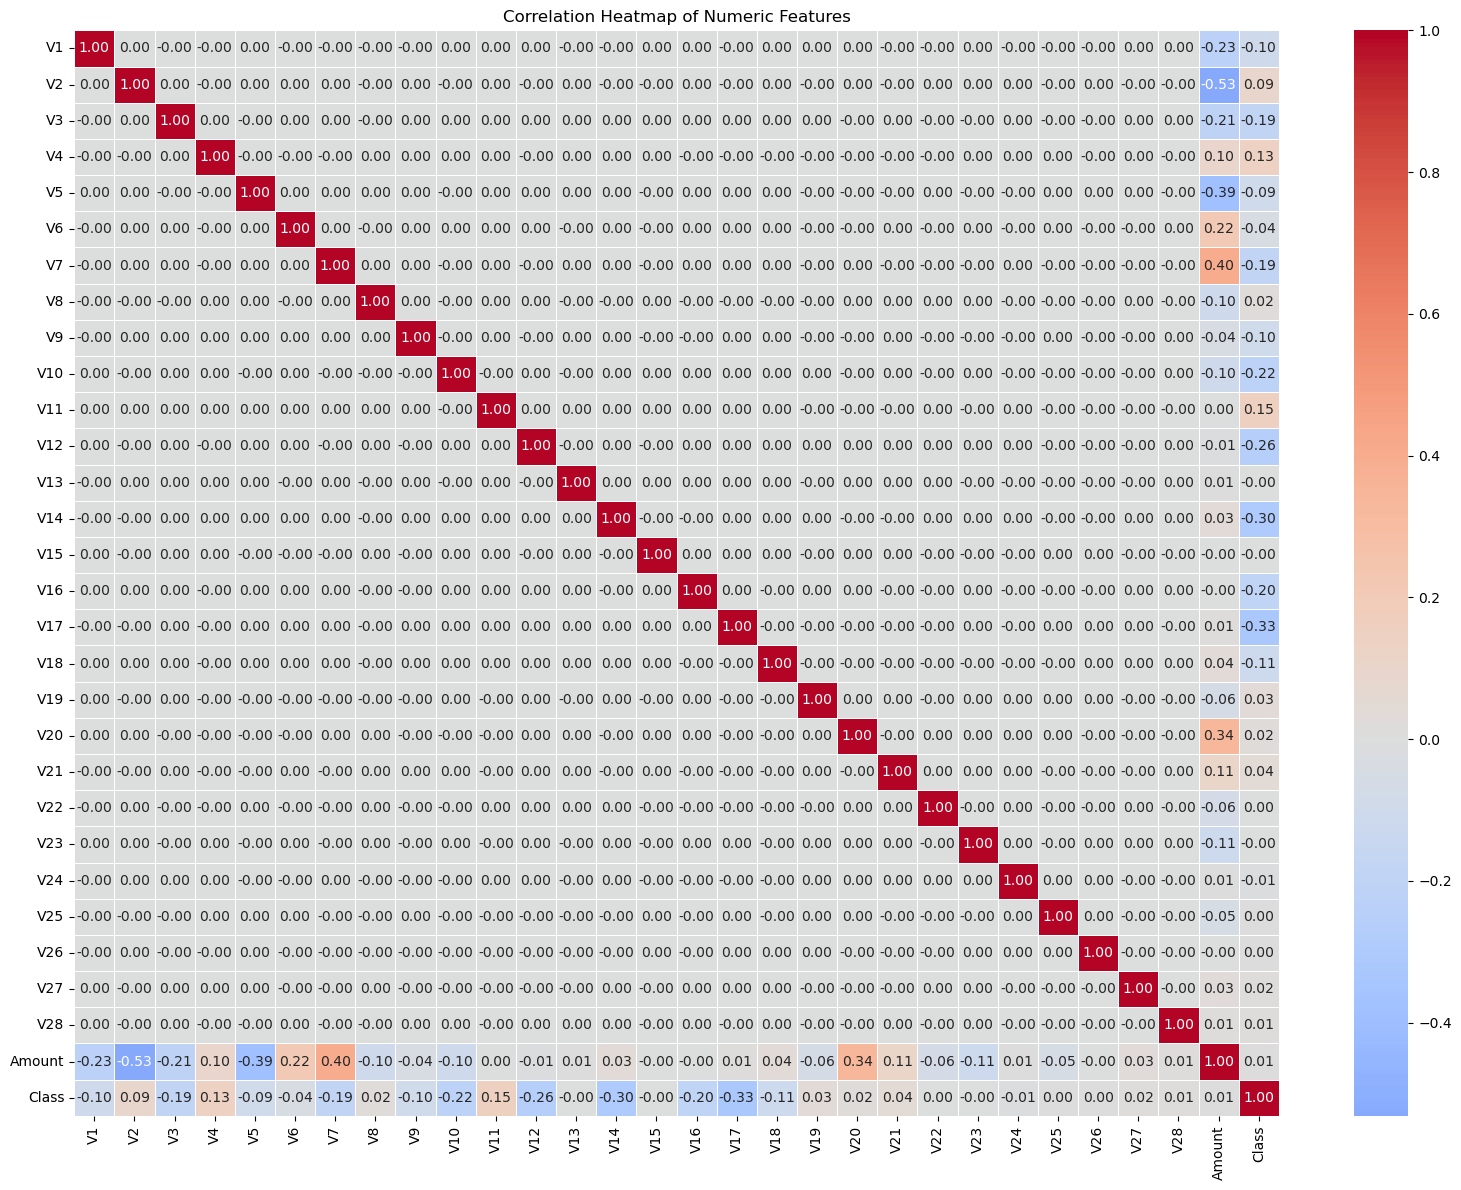

In [10]:
# Generate Heatmap for numeric variables -

# Select only numeric columns (excluding 'Time')

numeric_df = df.select_dtypes(include='number').drop(columns=['Time'])

# Compute the correlation matrix

correlation_matrix = numeric_df.corr()

# Plot the heatmap

plt.figure(figsize=(16, 12))

# using Seaborn.heatmap(), generate a plot for heatmap
sns.heatmap(correlation_matrix,cmap='coolwarm',center=0,linewidths=0.5,annot=True,fmt=".2f")

plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


Interpretation of Heatmap - 

Variables V10, V12, V14, V17 ,Amount : These are the high correlation variables .

V10,V12,V14,V17 having highest negative correlation with class. 

### 6. Pairplot for high correlation variables - 

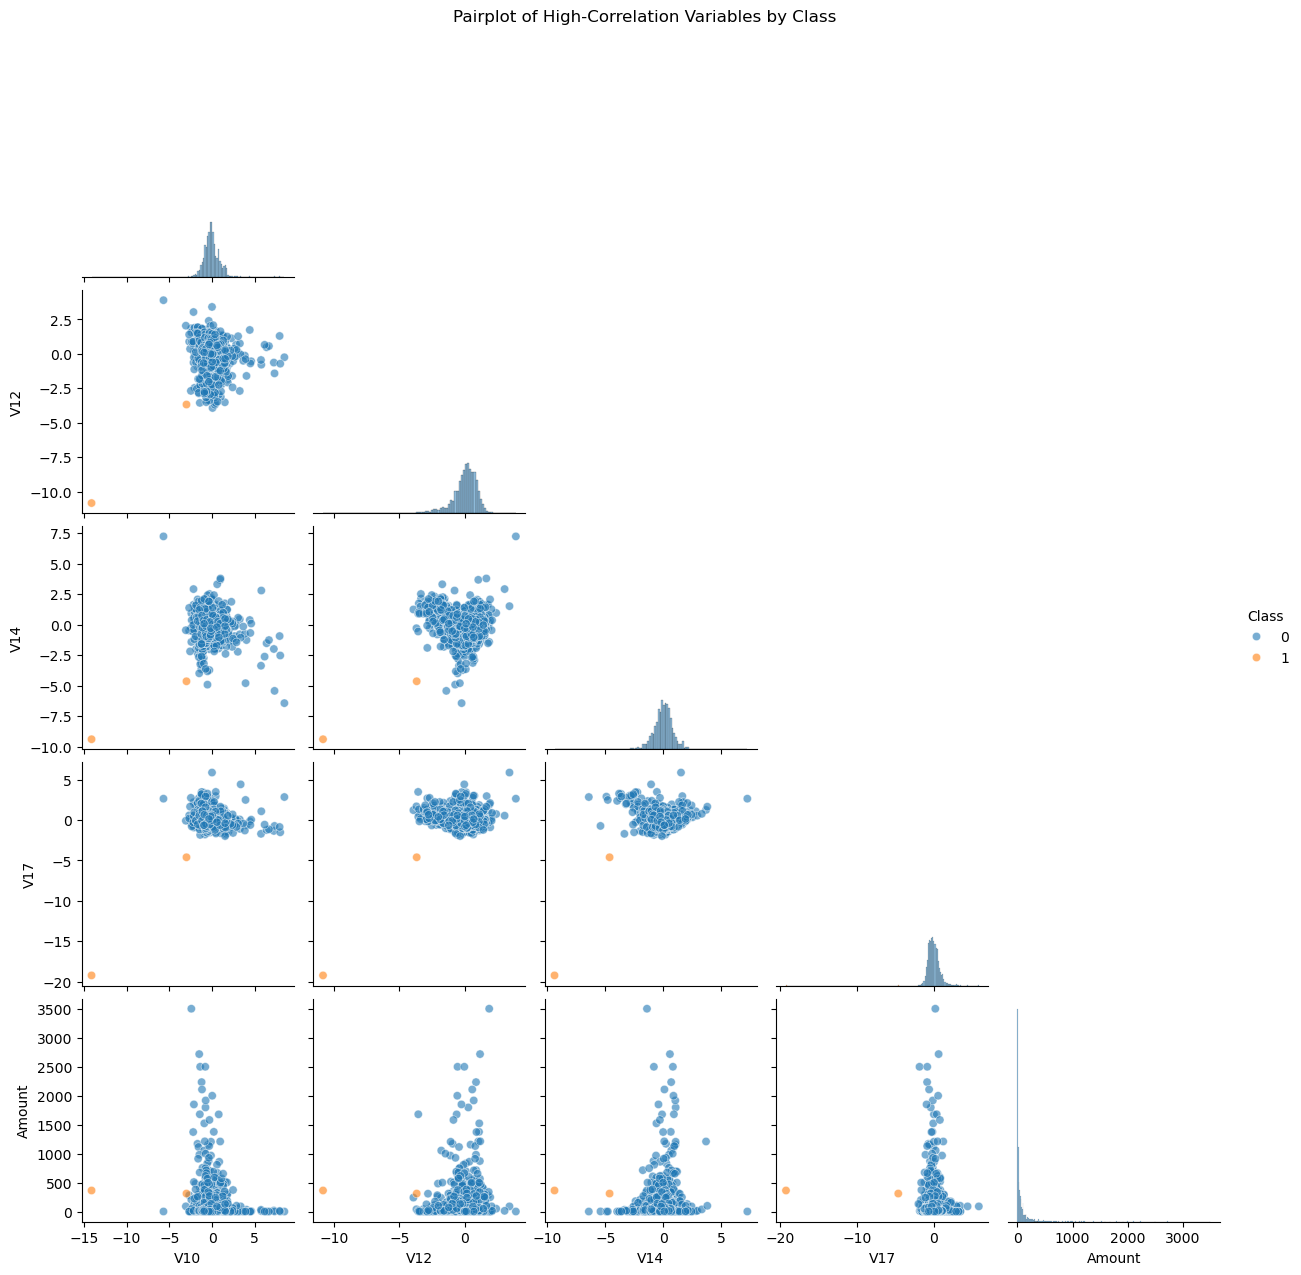

In [11]:
# Generate Pairplot with high correlation variables - 

pairplot_vars = ['V10', 'V12', 'V14', 'V17', 'Amount', 'Class']

# Sample the data for visualization (optional, to speed up plotting)
df_sample = df[pairplot_vars].sample(2000, random_state=42)

# Create the pairplot, coloring by fraud class
sns.pairplot(df_sample,hue='Class',diag_kind='hist',plot_kws={'alpha':0.6},corner=True)
plt.suptitle('Pairplot of High-Correlation Variables by Class', y=1.02)
plt.show()


Interpretation of above Pairplot :

- Each scatterplot shows the relationship between two features, 
colored by fraud class (0 = non-fraud, 1 = fraud).

-Diagonal plots show the distribution of each feature by class.

### 7. Violin Plot

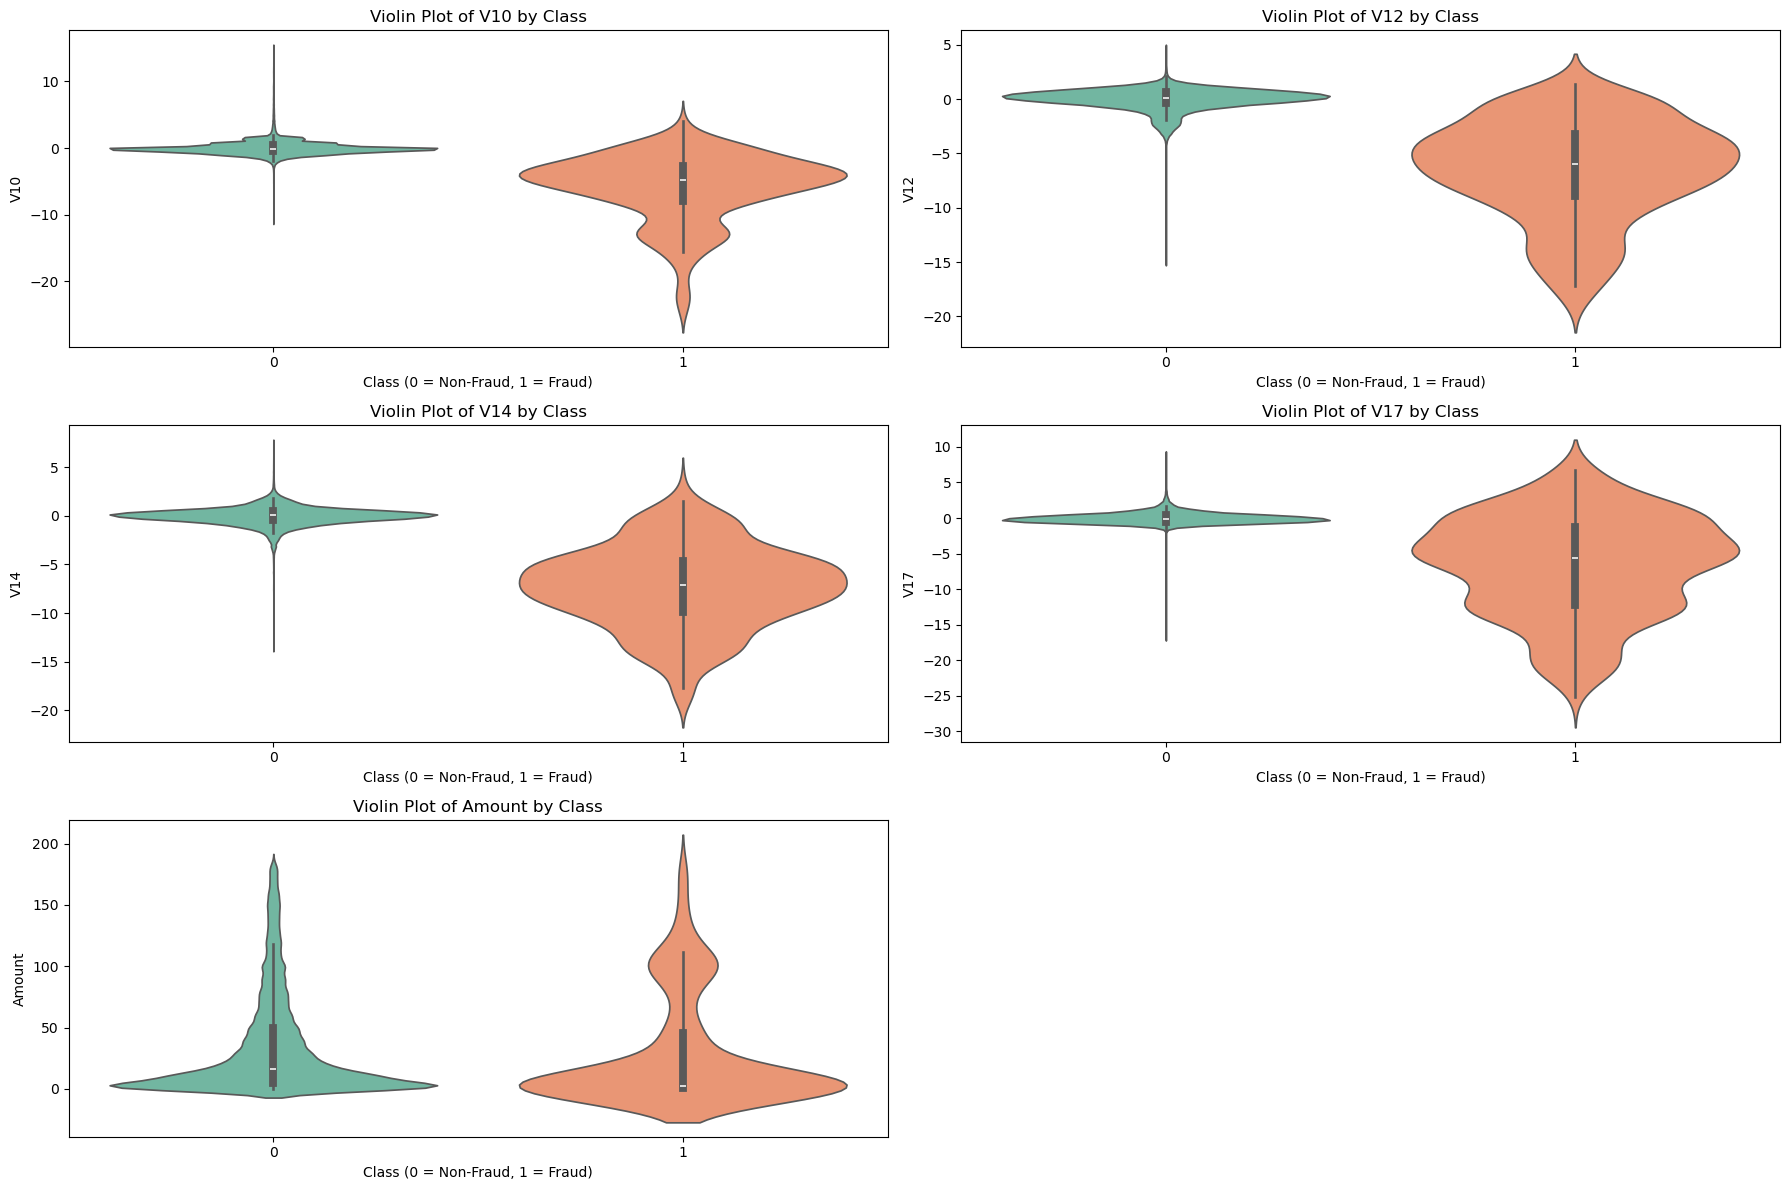

In [12]:
# Create violin plots for each feature (excluding 'Class') by Class

pairplot_vars = ['V10', 'V12', 'V14', 'V17', 'Amount', 'Class']

# Create violin plots using 'Class' as hue
plt.figure(figsize=(18, 12))
for i, feature in enumerate(pairplot_vars[:-1], 1):  # skip 'Class'
    plt.subplot(3, 2, i)
    sns.violinplot(data=df_clean, x='Class', y=feature, hue='Class', palette='Set2', legend=False)
    plt.title(f'Violin Plot of {feature} by Class')
    plt.xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

Interpretation of above violin plot -

1. V10, V12, V14 - Tight, narrow violins on the fraud side (Class = 1), all concentrated in negative ranges.
Non-fraud (Class = 0) distributions are wider and more symmetric, covering a broader value range.
Conclusion: These variables help separate fraud cases effectively due to tight 
value clusters for fraud.

2. V17- Shows a moderate peak for fraud around a narrow negative band.
Still valuable but less sharply separated than V10–V14.

3. Amount- Fraud transactions mostly occur at lower monetary values, forming a left-skewed, 
sharp peak.Non-fraud transactions span a much wider range, including high-value purchases.
Conclusion: While not mathematically correlated strongly, 
Amount shows a useful behavioral signal.

### 8. Fraud-Rate over Time 

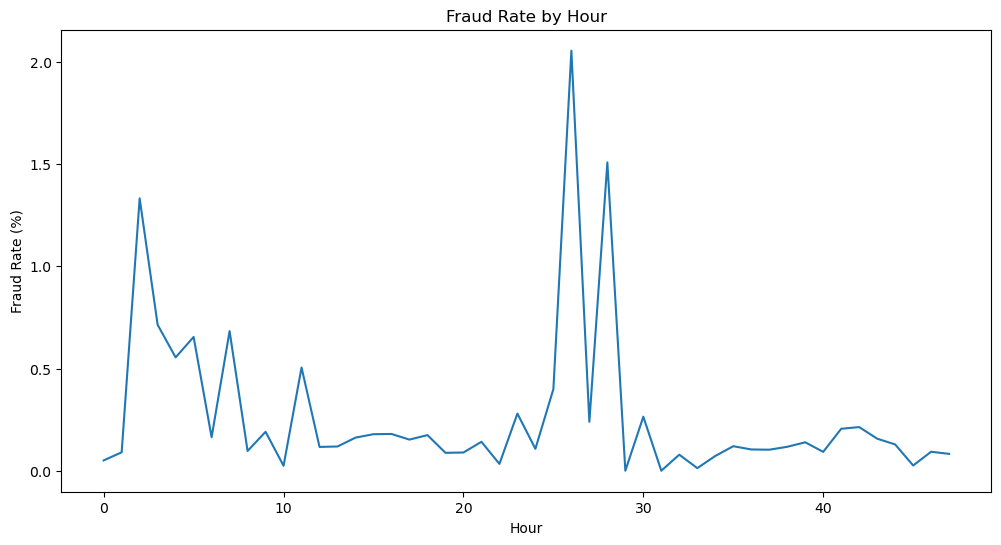

In [13]:
# Convert Time to hours
df['Hour'] = df['Time'] // 3600

# Calculate fraud rate per hour
fraud_rate = df.groupby('Hour')['Class'].mean() * 100

plt.figure(figsize=(12, 6))

# Plot the calculated data -

fraud_rate.plot()
plt.title('Fraud Rate by Hour')
plt.ylabel('Fraud Rate (%)')

# Display the results 
plt.show()

Interpretation - 

1. Long periods of near-zero fraud:The vast majority of hourly bins show very low fraud rates, 
close to 0. This highlights how rare fraudulent transactions are in this dataset.

2. Distinct spikes in specific hours: Noticeable spikes in fraud rate at a few specific hour bins.
These could represent:
- Coordinated fraud attempts during specific times.
- Anomalies or outliers worth investigating further.
- Time windows where existing fraud defenses were weaker.
    
3. Temporal clustering of fraud: Some neighboring hours show elevated fraud — a sign that 
fraudsters may be active in bursts.

### 9. Fraud by Amount bins 

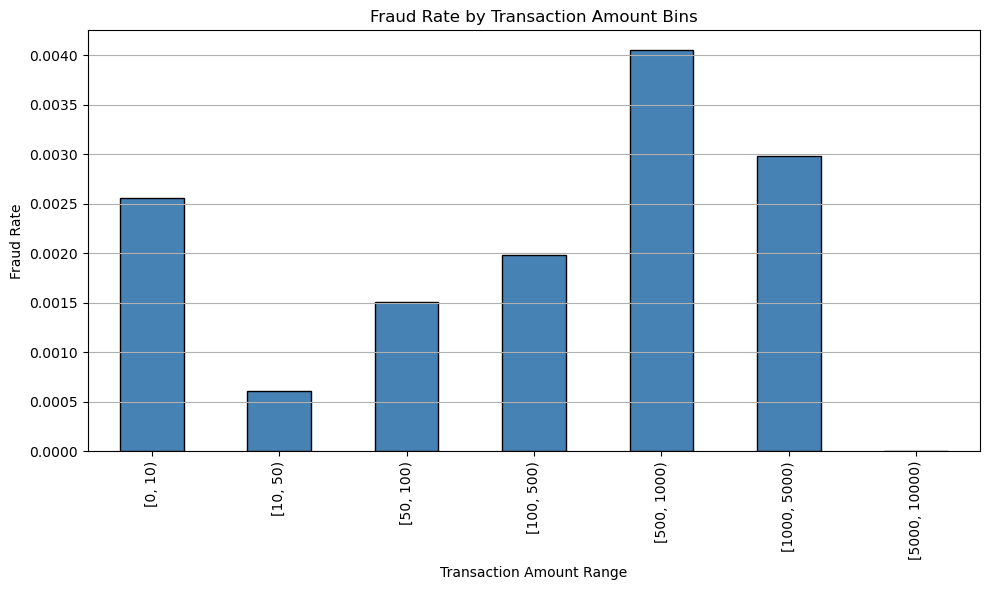

In [14]:
# Bin transaction amounts

# Create custom bins for transaction amounts
amount_bins = pd.cut(df['Amount'],bins=[0, 10, 50, 100, 500, 1000, 5000, 10000],
                     right=False  # so ranges are [start, end)
)

# Group by amount bins and calculate mean fraud rate
fraud_by_amount_bin = df.groupby(amount_bins,observed=True)['Class'].mean()

# Plot the fraud rate by amount bins
plt.figure(figsize=(10, 6))

fraud_by_amount_bin.plot(kind='bar', color='steelblue', edgecolor='black')

# Set title of the bar chart 

plt.title('Fraud Rate by Transaction Amount Bins')
plt.xlabel('Transaction Amount Range')
plt.ylabel('Fraud Rate')
plt.grid(axis='y')
plt.tight_layout()

# Display results 
plt.show()

Insights -
Fraud is not evenly distributed across transaction sizes.
Small-dollar fraud is frequent and must be closely monitored.
High-dollar fraud is rarer, but more damaging when it happens.

Fraud Rate Trend identified - 
$0–$10	- Highest Risk , Fraudsters commonly use small-dollar purchases to test stolen cards. 
These are low-risk and often go unnoticed.
